In [1]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch
from tqdm import tqdm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
from collections import Counter


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.14.0 (v3.14.0:ebf955df7a8, Oct  7 2025, 08:20:14) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:
import os
import pandas as pd

def load_common_data(folder_path, min_files=10, encoding="latin1", print_progress=False):
    file_columns = {}

    # --- Step 1: Read headers safely ---
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            path = os.path.join(folder_path, file)
            try:
                df = pd.read_csv(path, nrows=0, encoding=encoding)
                file_columns[file] = set(df.columns)
            except Exception as e:
                print(f"⚠ Skipping {file} during scan: {e}")

    if len(file_columns) < min_files:
        raise ValueError(f"Not enough readable files. Found {len(file_columns)}")

    # --- Step 2: Start with file that has the most columns ---
    sorted_files = sorted(file_columns.items(), key=lambda x: len(x[1]), reverse=True)

    selected_files = [sorted_files[0][0]]
    current_common = set(sorted_files[0][1])

    if print_progress:
        print(f"\n Starting with: {os.path.splitext(selected_files[0])[0]} ({len(current_common)} cols)")

    remaining_files = {f: cols for f, cols in sorted_files[1:]}

    # --- Step 3: Greedily add files that maximize remaining common columns ---
    while len(selected_files) < min_files and remaining_files:
        best_file = None
        best_intersection = set()

        for f, cols in remaining_files.items():
            intersection = current_common.intersection(cols)

            if len(intersection) > len(best_intersection):
                best_file = f
                best_intersection = intersection

        if best_file is None or len(best_intersection) == 0:
            print("⚠ No more compatible files can be added without losing all columns.")
            break

        selected_files.append(best_file)
        current_common = best_intersection

        if print_progress:
            print(f" + Added: {os.path.splitext(best_file)[0]} → {len(current_common)} common cols")

        del remaining_files[best_file]

    # --- Final report ---
    if print_progress:
        print(f"\n Final selected {len(selected_files)} files:")
    for f in selected_files:
        if print_progress:
            print(f" - {os.path.splitext(f)[0]} ({len(file_columns[f])} cols)")

    if print_progress:
        print(f"\n Final shared columns: {len(current_common)}")
        print(sorted(current_common))

    # --- Step 4: Load data ---
    dataframes = []

    for file in selected_files:
        path = os.path.join(folder_path, file)
        try:
            df = pd.read_csv(path, usecols=lambda c: c in current_common, encoding=encoding)

            season = os.path.splitext(file)[0]
            df["Season"] = season

            dataframes.append(df)
        except Exception as e:
            print(f"⚠ Skipping {file} during load: {e}")

    final_df = pd.concat(dataframes, ignore_index=True)

    return final_df, selected_files, list(current_common)

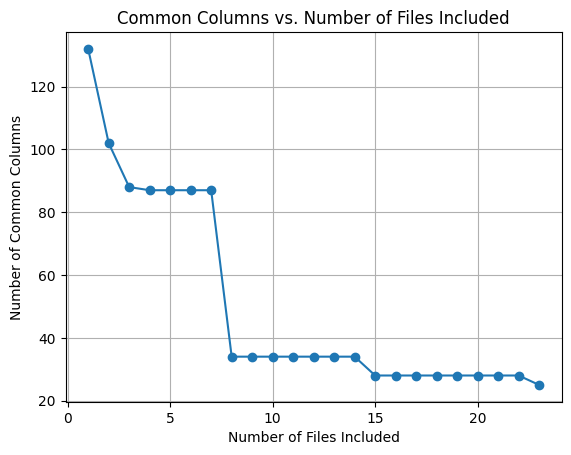

In [3]:
dataPath = "Data"
final_df, num_cols = [], []
for i in range(1, 24):
    df, _, cols = load_common_data(dataPath, min_files=i)
    final_df.append(df)
    num_cols.append(len(cols))    
plt.plot(range(1, 24), num_cols, marker='o')
plt.xlabel('Number of Files Included')
plt.ylabel('Number of Common Columns')
plt.title('Common Columns vs. Number of Files Included')
plt.grid()
plt.show()



## Multi-Season Dataset Construction (Greedy Alignment)

A greedy approach was used to build a consistent dataset across multiple football seasons.

The process starts with the season containing the most columns, then iteratively adds seasons that preserve the largest possible overlap of shared columns. At each step, the set of common columns is updated to ensure all selected seasons remain compatible.

After selecting the final group of seasons, only the columns shared across all of them are kept, and each season is loaded into a single combined DataFrame.

This ensures a consistent feature set across seasons while maximizing the number of usable datasets included.

We have chosen to include 7 seasons in our our pattern mining analysis, which provides a good balance between data richness and consistency.

In [4]:
data, selected_files, common_cols = load_common_data(dataPath, min_files=7)
print(f"Selected files: {sorted(selected_files)}")
print(f"Number of common columns: {len(common_cols)}")

Selected files: ['20192020premierleague.csv', '20202021premierleague.csv', '20212022premierleague.csv', '20222023premierleague.csv', '20232024premierleague.csv', '20242025premierleague.csv', '20252026premierleague.csv']
Number of common columns: 87


In [5]:
list_of_bookmakers = ['1XB', 'B365', 'BF', 'BFD', 'BMGM', 'BV', 'BS', 'BW',
                      'CL', 'GB', 'IW', 'LB', 'PS', 'SO', 'SB', 'SJ', 'SY', 'VC', 'WH']

# assuming df is your final dataframe
cols = common_cols

present_bookmakers = set()

for b in list_of_bookmakers:
    if any(col.startswith(b) for col in cols):
        present_bookmakers.add(b)

print("Present bookmakers:", sorted(present_bookmakers))
print("Count:", len(present_bookmakers))


Present bookmakers: ['B365', 'BW', 'PS']
Count: 3


In [6]:
#relevant_cols = [c for c in common_cols if c.startswith("B365") or c.startswith("BW") or c.startswith("PS")]
prefixes = ["B365", "BW", "PS"]
suffixes = ["A", "H", "D"]

valid_cols = {p + s for p in prefixes for s in suffixes}

relevant_cols = [c for c in common_cols if c in valid_cols]
print(f"Relevant columns include: {relevant_cols}\nnumber of columns: {len(relevant_cols)}")

Relevant columns include: ['BWD', 'BWA', 'PSA', 'PSD', 'B365A', 'PSH', 'B365D', 'B365H', 'BWH']
number of columns: 9


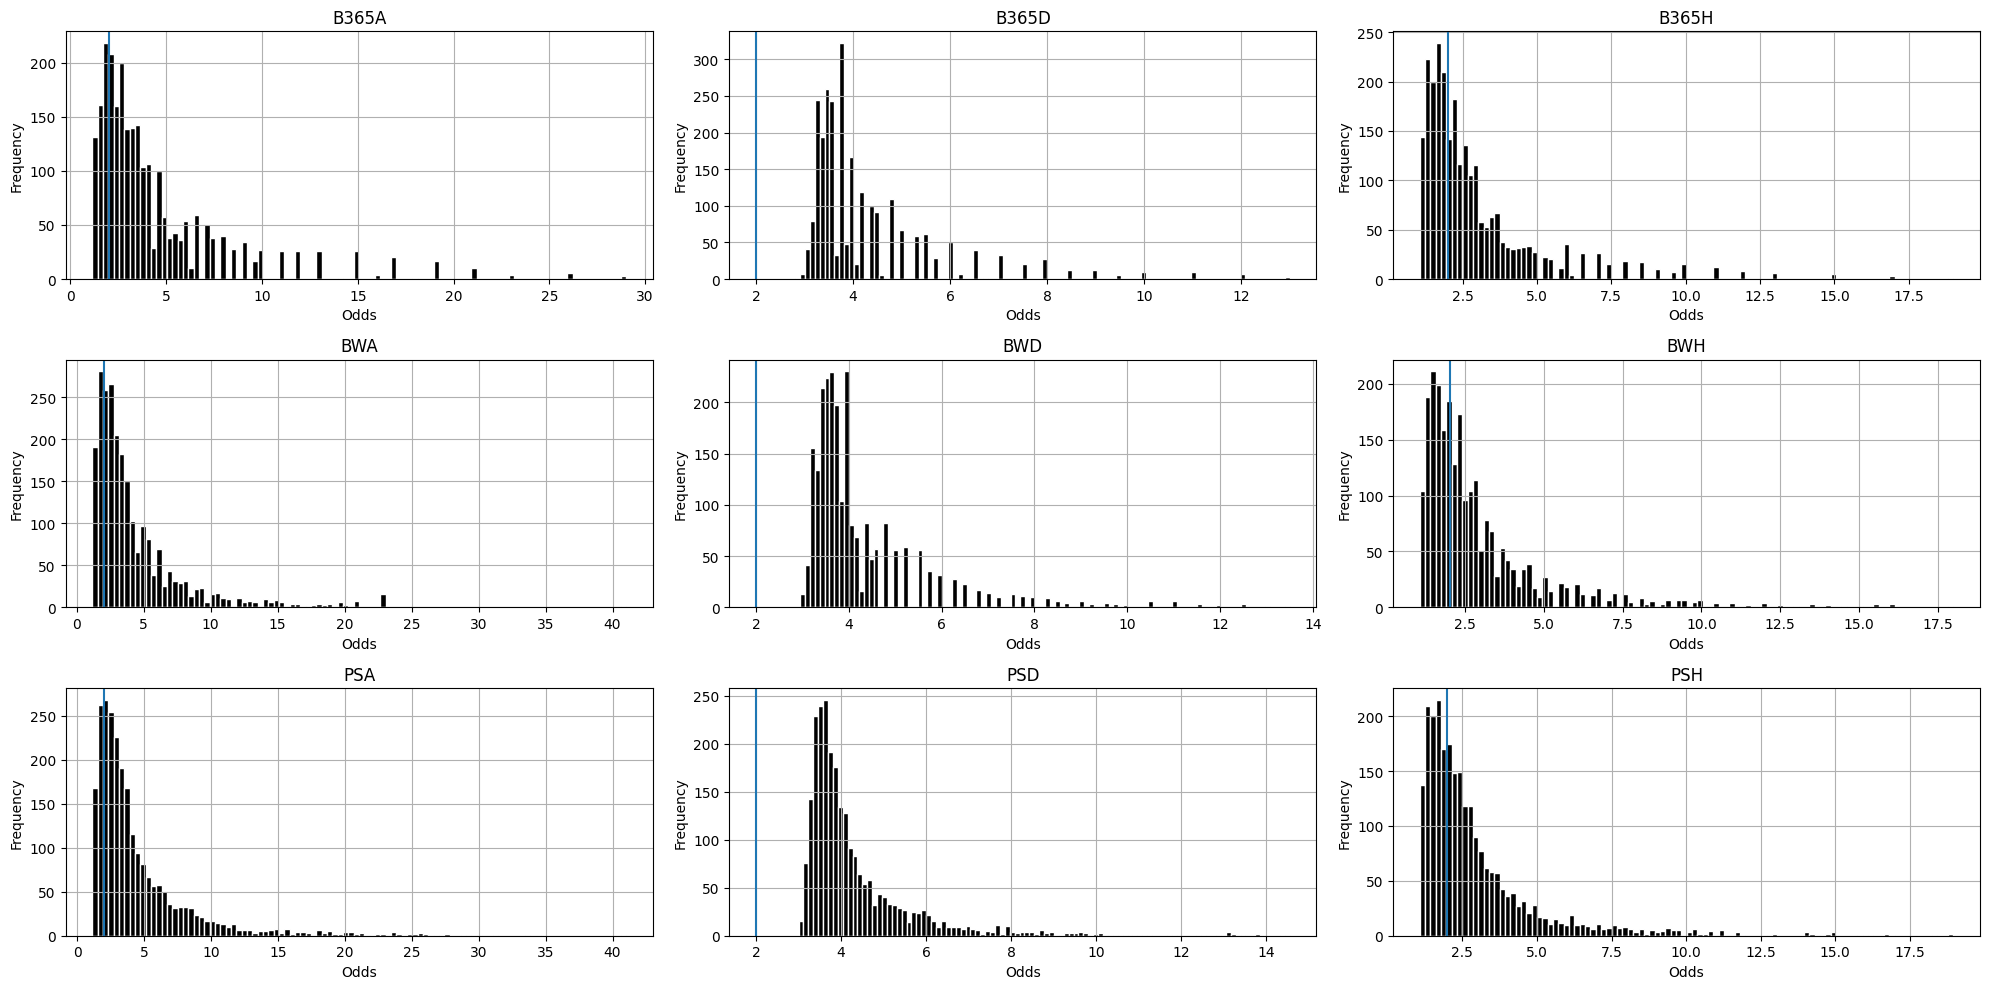

In [28]:
fig, ax = plt.subplots(3, 3, figsize=(20, 10))
ax = ax.flatten()

for i, c in enumerate(sorted(relevant_cols)):
    if i >= len(ax):  # safety in case more columns than plots
        break

    data_col = data[c].dropna()

    ax[i].hist(data_col, bins=100, edgecolor='white', color='k')
    ax[i].set_title(f"{c}")
    ax[i].set_xlabel("Odds")
    ax[i].axvline(2)
    ax[i].set_ylabel("Frequency")
    ax[i].grid(True)

# hide unused subplots (if any)
for j in range(i + 1, len(ax)):
    ax[j].axis("off")

plt.tight_layout()
plt.show()

Based on the distributions above we notice that it may not make sense to use the same discretization for all columns, as the 'draw' distributions differ significantly from the 'home win' and 'away win' distributions. We will therefore use different discretization bins.

In [34]:
bins_HA = [0, 1.5, 2.0, 3.0, 5.0, 10.0, np.inf]
labels_HA = ["0-1.5", "1.5-2.0", "2.0-3.0", "3.0-5.0", "5.0-10.0", "10.0+"]

bins_D = [0, 3.5, 4.0, 5.0, 10.0, np.inf]
labels_D = ["0-3.5", "3.5-4.0", "4.0-5.0", "5.0-10.0", "10.0+"]

def discretize_odds(series, bins, labels):
    return pd.cut(series, bins=bins, labels=labels)

discrete_data = data.copy()
for c in relevant_cols:
    if c.endswith("D"):
        discrete_data[c] = discretize_odds(discrete_data[c], bins=bins_D, labels=labels_D)
    else:
        discrete_data[c] = discretize_odds(discrete_data[c], bins=bins_HA, labels=labels_HA)
discrete_data[relevant_cols]
# Investigate this bining by looking at amount of data in each bin
for c in relevant_cols:
    print(f"Distribution for {c}:")
    print(discrete_data[c].value_counts())
    print()

Distribution for BWD:
BWD
0-3.5       781
3.5-4.0     760
4.0-5.0     489
5.0-10.0    345
10.0+        22
Name: count, dtype: int64

Distribution for BWA:
BWA
2.0-3.0     647
3.0-5.0     645
5.0-10.0    431
1.5-2.0     347
10.0+       165
0-1.5       162
Name: count, dtype: int64

Distribution for PSA:
PSA
3.0-5.0     685
2.0-3.0     632
5.0-10.0    485
1.5-2.0     325
10.0+       204
0-1.5       159
Name: count, dtype: int64

Distribution for PSD:
PSD
3.5-4.0     885
4.0-5.0     604
0-3.5       535
5.0-10.0    437
10.0+        29
Name: count, dtype: int64

Distribution for B365A:
B365A
3.0-5.0     678
2.0-3.0     672
5.0-10.0    475
1.5-2.0     362
0-1.5       183
10.0+       170
Name: count, dtype: int64

Distribution for PSH:
PSH
2.0-3.0     744
1.5-2.0     527
3.0-5.0     496
0-1.5       442
5.0-10.0    232
10.0+        49
Name: count, dtype: int64

Distribution for B365D:
B365D
0-3.5       826
3.5-4.0     812
4.0-5.0     512
5.0-10.0    370
10.0+        20
Name: count, dtype: int6

In [ ]:
def make_transactions(df, cols):
    T = []

    for _, row in df[cols].iterrows():
        items = []

        for c in cols:
            val = row[c]
            if pd.notna(val):
                items.append(f"{c}={val}")

        T.append(items)

    return T
T = make_transactions(discrete_data, relevant_cols)

rule  = lambda lhs, rhs: "%s => %s" % (str(lhs), str(rhs)) # For generating rule strings
from itertools import combinations, chain


def compute_support(Ck: list, T: list, still_applicable=None):
    """
    Function that computes the support of each candidate itemset in Ck with respect to the transactions in T.
    Parameters:
        Ck: list of candidate itemsets of size k
        T: list of transactions (each transaction is a list of items)
        still_applicable: a list of boolean values indicating whether each transaction is applicable
    Returns:
        counts: a list of counts corresponding to the support of each candidate itemset in Ck
    """
    if still_applicable is None:
        still_applicable = [True] * len(T)
        
    counts = {} # Dictionary to store counts of each candidate itemset slide 40
    for row, t in enumerate(T):
        if not still_applicable[row]: continue
        found_any = False
        for c in Ck:
            if set.issubset(set(c), t):
                if c in counts:
                    counts[c] += 1
                else:
                    counts[c] = 1
                found_any = True
        still_applicable[row] = found_any
    return counts

def extend_prefix_tree(Ck_prev):
    """
    Function that extends the prefix tree by generating new candidate itemsets of size k+1 from the previous candidate itemsets of size k.
    Parameters:
        Ck_prev: list of candidate itemsets of size k
    Returns:
        Ck: list of candidate itemsets of size k+1
    """
    Ck = set() 
    #join step
    for itemset in Ck_prev:
        its1 = tuple(sorted(itemset))
        for itemset2 in Ck_prev:
            its2 = tuple(sorted(itemset2))
            if its1[:-1] == its2[:-1] and its1 < its2: Ck.add(its1 + its2[-1:]) # Join step: if the first k-1 items are the same and the last item is different, we can join them
    #prune step
    to_remove = set()
    for c in Ck:
        for subset in combinations(c, len(c) - 1):
            if subset not in Ck_prev:
                to_remove.add(c)
                break            
    for c in to_remove:
        Ck.remove(c)
    return Ck

def powerset(iterable):
    """
    Function that generates the powerset of a given iterable.
    Parameters: 
            iterable: an iterable (e.g., list, set, etc.) for which to generate the powerset
    Returns:
            A list of all subsets of the input iterable      
    """
    s = list(iterable)
    out = chain.from_iterable(combinations(s, r) for r in range(1, len(s))) # Generate all non-empty subsets
    return out

def get_outcome(item):
    col = item.split("=")[0]  # "PSD"
    return col[-1]            # "D"

def apriori_algorithm(T, support=0.05, min_confidence=0.7):
    """
        Apriori algorithm for mining association rules.
        Inputs:
            T:               A list of lists, each inner list will contiain integer-item-ids. 
                             Example: T = [[1, 2, 5], [2, 3, 4], [1, 6]]
            support:         The proportion of occurences needed to keep itemsets.
            min_confidence:  Minimum confidence for the algorithm to output the rule.
    """        
    rules = []
    # --- Generate frequent itemsets using the Apriori algorithm ---
    N = len(T) # Total number of transactions
    # Construct the initial candidate itemsets of size 1
    items = set(i for t in T for i in t) # Get all unique items in the transactions
    C1 = set((i,) for i in items) # Convert to set of tuples for consistency with later itemsets
    counts = compute_support(C1, T) # Compute support for itemsets of size 1
    L1 = [c for c in counts if counts[c] / N >= support] # Filter itemsets by support
    L = [L1]
    support_dict = {c: counts[c] / N for c in L1} # Store support values for itemsets of size 1
    # Second step
    k = 2
    while L[k-2]: # While there are itemsets of size k-1
        Ck = extend_prefix_tree(L[k-2]) # Generate candidate itemsets of size k
        print(k)
        if not Ck: break # If no candidates, stop

        counts = compute_support(Ck, T) # Compute support for itemsets of size k
        Lk = []
        for i in Ck:
            supp = counts.get(i, 0) / N # Get support for itemset i, default to 0 if not found
            if supp >= support:
                Lk.append(i) # Keep itemsets that meet the support threshold
                support_dict[i] = supp # Store support value for itemset i
        if not Lk: break # If no itemsets meet the support threshold, stop
        L.append(Lk) # Add the frequent itemsets of size k to the list
        k += 1    
    # --- Generate rules from the frequent itemsets ---  
    for Lk in L:
        for itemset in Lk:
            if len(itemset) < 2: continue # We need at least 2 items to form a rule

            for A in powerset(itemset):
                B = tuple(sorted(set(itemset) - set(A))) # Get the remaining items as B
                if not B: continue # Skip if B is empty

                if

                conf = support_dict[itemset] / support_dict[A] # Calculate confidence of the rule A => B
                if conf >= min_confidence:
                    rules.append((rule(A, B), conf)) # Store the rule along with its confidence
    return rules
support = 0.2
min_confidence = 0.8                
rules = apriori_algorithm(T, support=support, min_confidence=min_confidence)
print(f"Generated {len(rules)} rules with support >= {support} and confidence >= {min_confidence}")
print("Sample rules:")
rules

2
3
4
Generated 48 rules with support >= 0.2 and confidence >= 0.8
Sample rules:


[("('PSD=0-3.5',) => ('B365D=0-3.5',)", 0.9850467289719627),
 ("('BWD=3.5-4.0',) => ('B365D=3.5-4.0',)", 0.8421052631578947),
 ("('BWH=2.0-3.0',) => ('PSH=2.0-3.0',)", 0.8806179775280898),
 ("('PSH=2.0-3.0',) => ('BWH=2.0-3.0',)", 0.8427419354838709),
 ("('B365A=3.0-5.0',) => ('PSA=3.0-5.0',)", 0.8908554572271387),
 ("('PSA=3.0-5.0',) => ('B365A=3.0-5.0',)", 0.8817518248175182),
 ("('BWA=3.0-5.0',) => ('PSA=3.0-5.0',)", 0.8682170542635659),
 ("('PSA=3.0-5.0',) => ('BWA=3.0-5.0',)", 0.8175182481751824),
 ("('B365D=0-3.5',) => ('BWD=0-3.5',)", 0.8607748184019371),
 ("('BWD=0-3.5',) => ('B365D=0-3.5',)", 0.910371318822023),
 ("('B365H=1.5-2.0',) => ('BWH=1.5-2.0',)", 0.9238938053097345),
 ("('BWH=1.5-2.0',) => ('B365H=1.5-2.0',)", 0.9388489208633093),
 ("('B365H=2.0-3.0',) => ('PSH=2.0-3.0',)", 0.8949468085106383),
 ("('PSH=2.0-3.0',) => ('B365H=2.0-3.0',)", 0.9045698924731183),
 ("('B365A=3.0-5.0',) => ('BWA=3.0-5.0',)", 0.8997050147492625),
 ("('BWA=3.0-5.0',) => ('B365A=3.0-5.0',)", 0.